In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
import scipy.stats as stats
from scipy.stats import shapiro, jarque_bera
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
print('All libraries imported')

All libraries imported


In [5]:
df = pd.read_csv('insurance.csv')
print(f'Shape: {df.shape}')

Shape: (1338, 7)


In [6]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


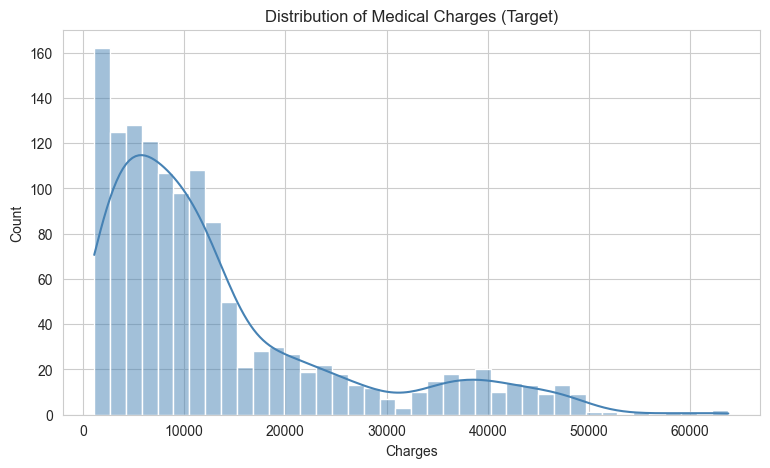

In [10]:
sns.histplot(df['charges'], kde=True, color='steelblue', bins=40)
plt.title('Distribution of Medical Charges (Target)')
plt.xlabel('Charges')
plt.show()

In [12]:
print(f'Skewness of charges: {df["charges"].skew():.4f}')
print('→ Right-skewed target — may violate normality assumption')

Skewness of charges: 1.5159
→ Right-skewed target — may violate normality assumption


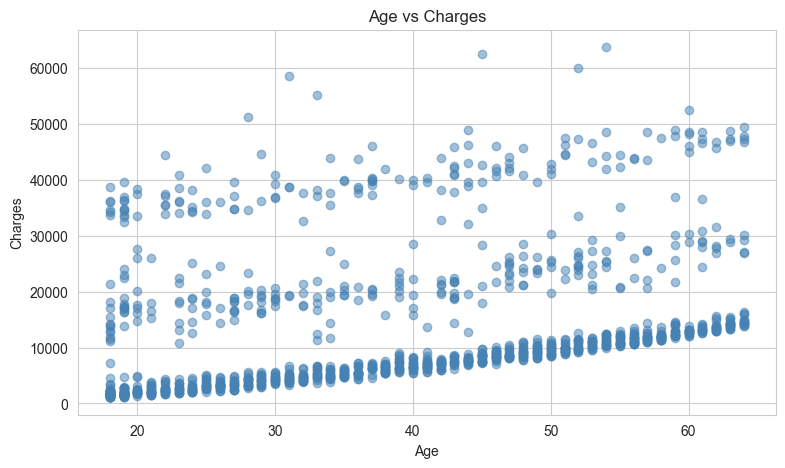

In [13]:
plt.scatter(df['age'], df['charges'], alpha=0.5, color='steelblue')
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

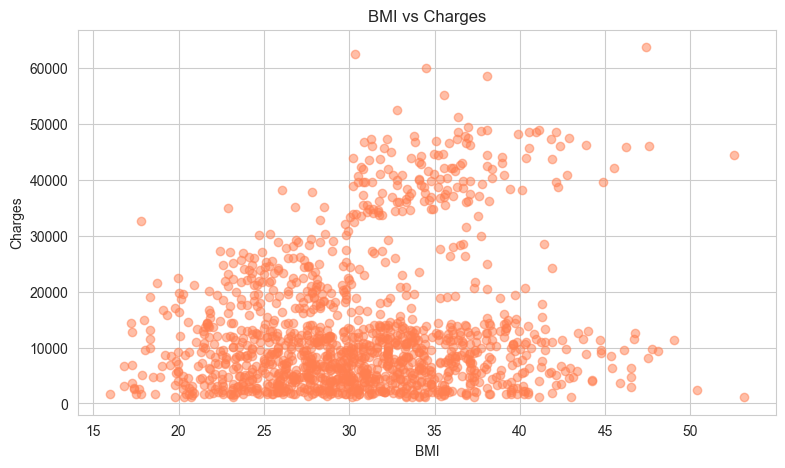

In [14]:
plt.scatter(df['bmi'], df['charges'], alpha=0.5, color='coral')
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

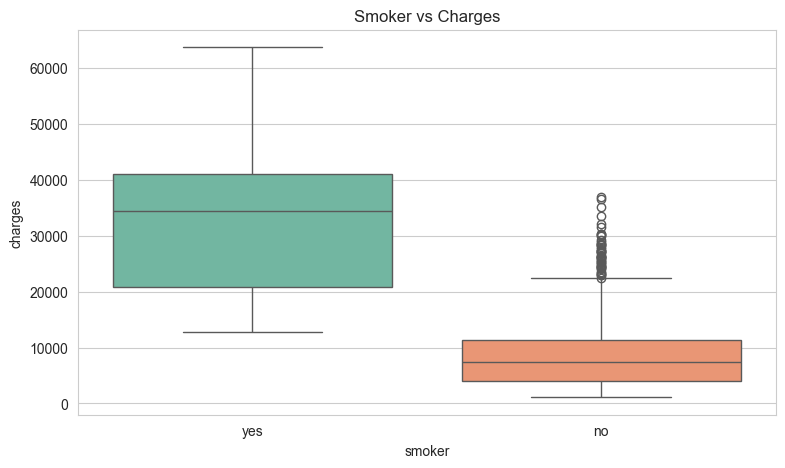

In [15]:
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Smoker vs Charges')
plt.show()

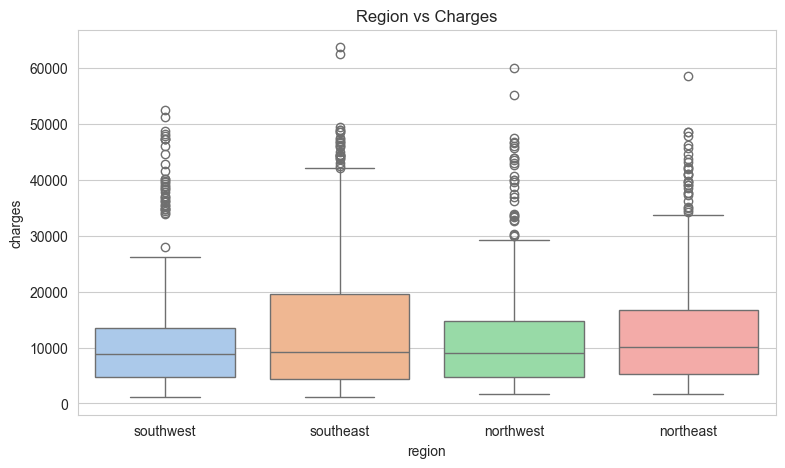

In [16]:
sns.boxplot(x='region', y='charges', data=df, palette='pastel')
plt.title('Region vs Charges')
plt.show()

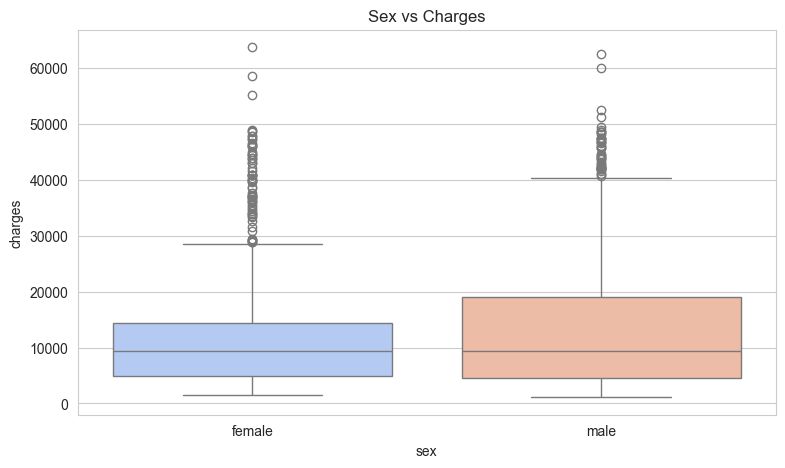

In [17]:
sns.boxplot(x='sex', y='charges', data=df, palette='coolwarm')
plt.title('Sex vs Charges')
plt.show()

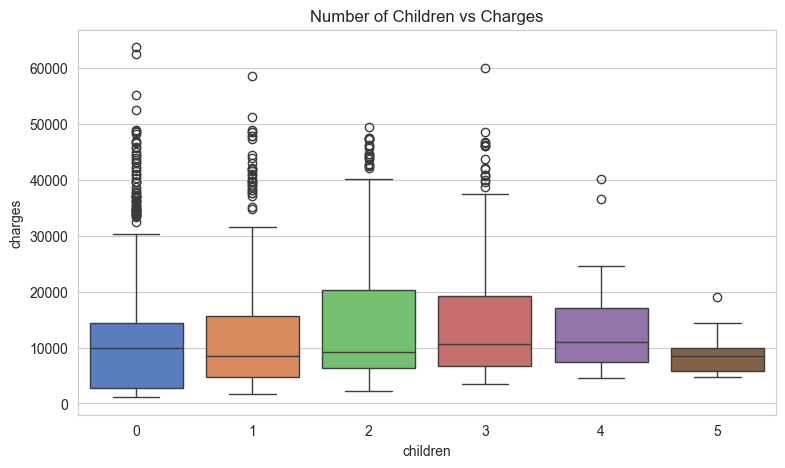

In [18]:
sns.boxplot(x='children', y='charges', data=df, palette='muted')
plt.title('Number of Children vs Charges')
plt.show()

In [19]:
df_corr = df.copy()
df_corr['smoker']  = df_corr['smoker'].map({'yes': 1, 'no': 0})
df_corr['sex']     = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['region']  = df_corr['region'].astype('category').cat.codes
df_corr.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.002127,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.004588,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.157566,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.016569,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.002181,0.787251
region,0.002127,0.004588,0.157566,0.016569,-0.002181,1.000000,-0.006208
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.006208,1.000000


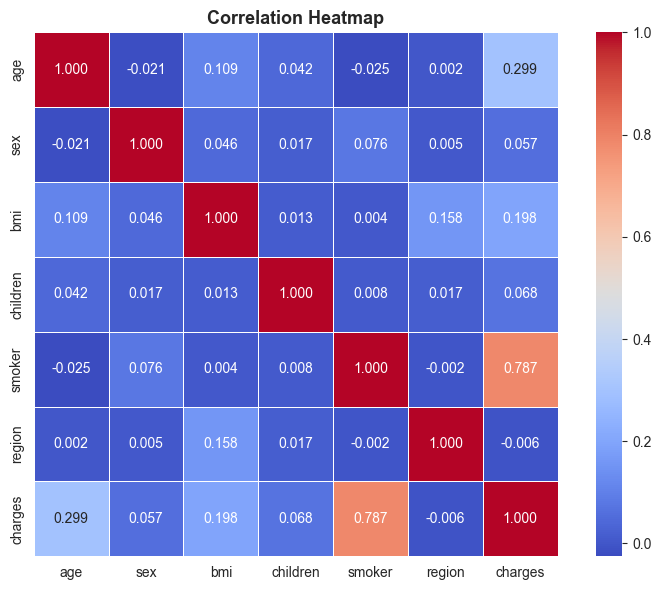

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

Categorical columns: ['sex', 'smoker', 'region']


In [22]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape after encoding:', df_encoded.shape)
df_encoded.head()

Shape after encoding: (1338, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [23]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

In [24]:
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']
print('Features:', list(X.columns))
print('Target  : charges')

Features: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Target  : charges


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 1070 | Test: 268


In [26]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained')

Model trained


In [27]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(f'Intercept: {model.intercept_:,.2f}')
coef_df

Intercept: -11,931.22


,Feature,Coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


In [28]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656])

In [29]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')

MAE  : 4,181.19
RMSE : 5,796.28
R²   : 0.7836


In [30]:
residuals = y_test - y_pred
print(f'Residual mean   : {residuals.mean():.4f}')
print(f'Residual std    : {residuals.std():.4f}')
print(f'Residual min    : {residuals.min():.4f}')
print(f'Residual max    : {residuals.max():.4f}')

Residual mean   : -219.2407
Residual std    : 5802.9734
Residual min    : -10512.5826
Residual max    : 22850.1365


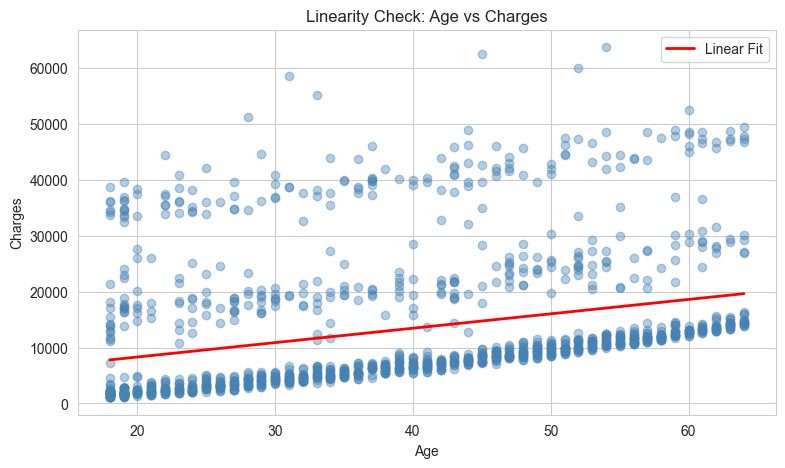

In [31]:
plt.scatter(df['age'], df['charges'], alpha=0.4, color='steelblue')
m, b = np.polyfit(df['age'], df['charges'], 1)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', lw=2, label='Linear Fit')
plt.title('Linearity Check: Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.show()

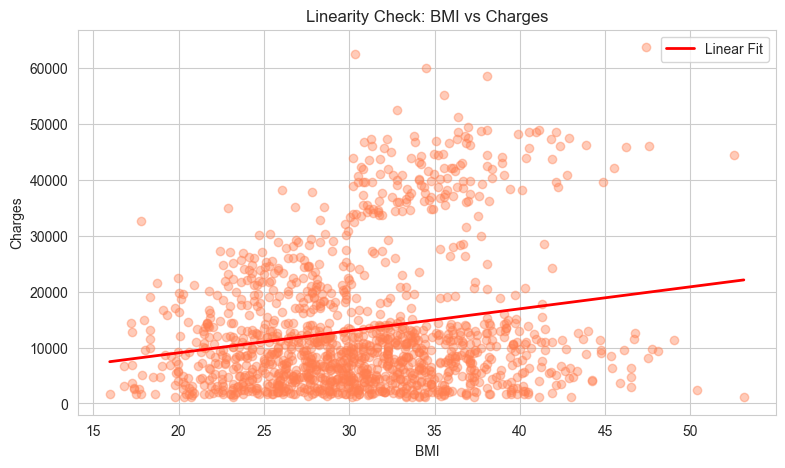

In [32]:
plt.scatter(df['bmi'], df['charges'], alpha=0.4, color='coral')
m2, b2 = np.polyfit(df['bmi'], df['charges'], 1)
x_line2 = np.linspace(df['bmi'].min(), df['bmi'].max(), 100)
plt.plot(x_line2, m2 * x_line2 + b2, color='red', lw=2, label='Linear Fit')
plt.title('Linearity Check: BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend()
plt.show()

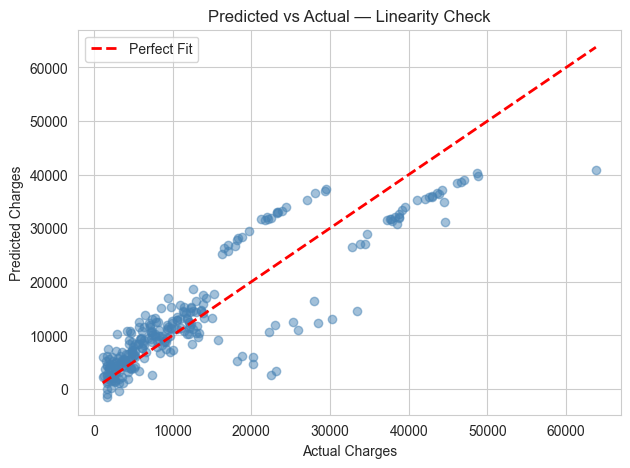

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Predicted vs Actual — Linearity Check')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.show()

In [34]:
print('Linearity Check:')
print('  The Predicted vs Actual plot shows points scattered around the diagonal.')
print('  However, high-charge predictions fan out → suggests NON-linearity.')
print('  Reason: Smoker status causes a bimodal distribution in charges.')
print('  → Linearity assumption is PARTIALLY violated.')

Linearity Check:
  The Predicted vs Actual plot shows points scattered around the diagonal.
  However, high-charge predictions fan out → suggests NON-linearity.
  Reason: Smoker status causes a bimodal distribution in charges.
  → Linearity assumption is PARTIALLY violated.


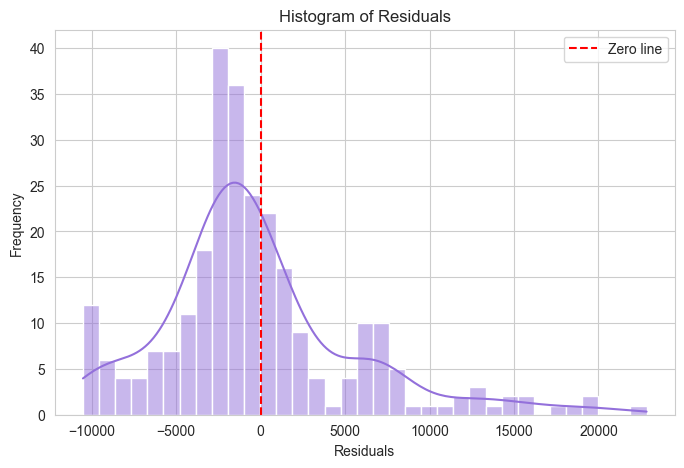

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='mediumpurple', bins=35)
plt.axvline(0, color='red', linestyle='--', label='Zero line')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [36]:
print(f'Residual Skewness : {residuals.skew():.4f}')
print(f'Residual Kurtosis : {residuals.kurtosis():.4f}')
print()
print('Rule of thumb: |Skewness| < 0.5 and |Kurtosis| < 3 → approx normal')

Residual Skewness : 1.1373
Residual Kurtosis : 2.1143

Rule of thumb: |Skewness| < 0.5 and |Kurtosis| < 3 → approx normal


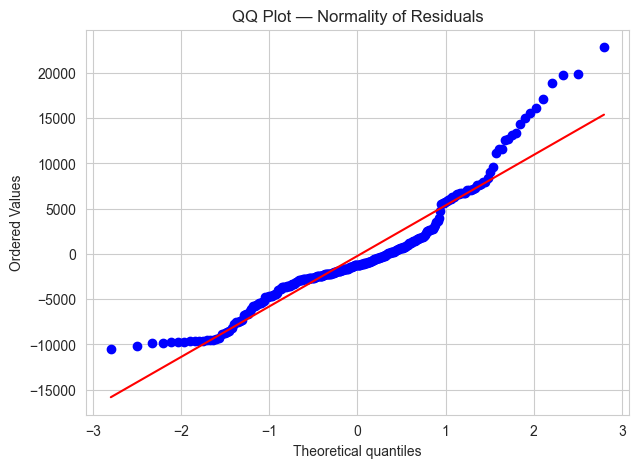

In [37]:
plt.figure(figsize=(7, 5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('QQ Plot — Normality of Residuals')
plt.show()

In [38]:
sample_residuals = residuals[:500] if len(residuals) > 500 else residuals
stat_sw, p_sw = shapiro(sample_residuals)
print(f'Shapiro-Wilk Test:')
print(f'  Statistic : {stat_sw:.4f}')
print(f'  p-value   : {p_sw:.6f}')
print()
if p_sw < 0.05:
    print('  → p < 0.05: Residuals are NOT normally distributed (reject H0)')
else:
    print('  → p ≥ 0.05: Residuals appear normally distributed (fail to reject H0)')

Shapiro-Wilk Test:
  Statistic : 0.9139
  p-value   : 0.000000

  → p < 0.05: Residuals are NOT normally distributed (reject H0)


In [39]:
stat_jb, p_jb = jarque_bera(residuals)
print(f'Jarque-Bera Test:')
print(f'  Statistic : {stat_jb:.4f}')
print(f'  p-value   : {p_jb:.6f}')
print()
if p_jb < 0.05:
    print('  → p < 0.05: Residuals are NOT normally distributed')
else:
    print('  → p ≥ 0.05: Residuals appear normally distributed')

Jarque-Bera Test:
  Statistic : 104.1783
  p-value   : 0.000000

  → p < 0.05: Residuals are NOT normally distributed


In [40]:
print('Normality Assumption:')
print('  - Histogram shows right skew → not a perfect bell curve')
print('  - QQ plot shows tails deviating from the diagonal')
print('  - Statistical tests confirm: residuals are NOT normally distributed')
print('  → Normality assumption is VIOLATED')

Normality Assumption:
  - Histogram shows right skew → not a perfect bell curve
  - QQ plot shows tails deviating from the diagonal
  - Statistical tests confirm: residuals are NOT normally distributed
  → Normality assumption is VIOLATED


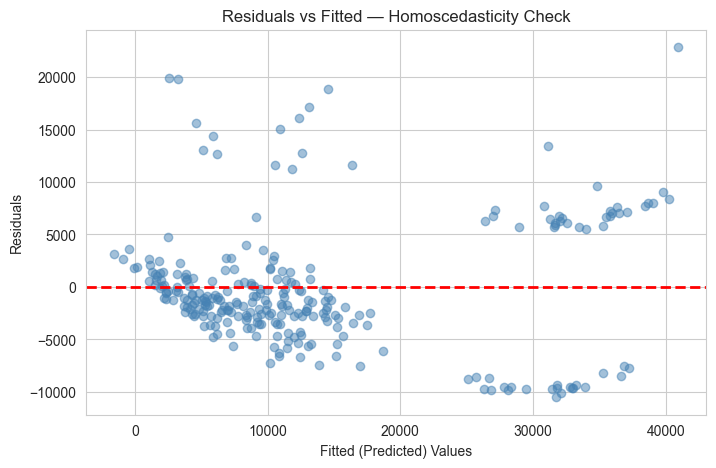

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals vs Fitted — Homoscedasticity Check')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.show()

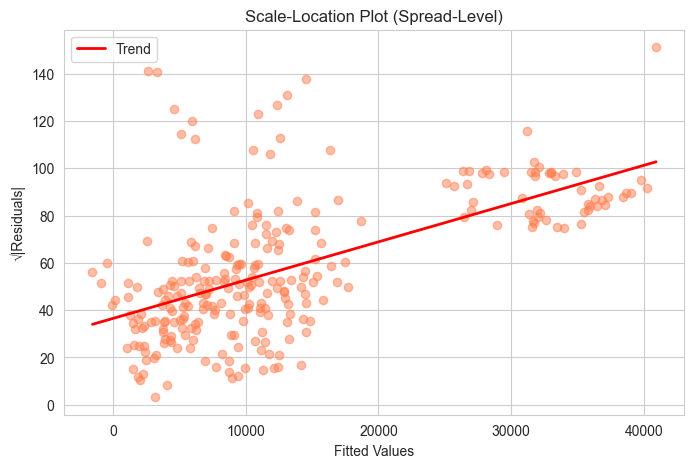

In [42]:
sqrt_abs_res = np.sqrt(np.abs(residuals))
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, sqrt_abs_res, alpha=0.5, color='coral')
plt.title('Scale-Location Plot (Spread-Level)')
plt.xlabel('Fitted Values')
plt.ylabel('√|Residuals|')

# Trend line
m3, b3 = np.polyfit(y_pred, sqrt_abs_res, 1)
x_trend = np.linspace(y_pred.min(), y_pred.max(), 100)
plt.plot(x_trend, m3 * x_trend + b3, color='red', lw=2, label='Trend')
plt.legend()
plt.show()

In [43]:
corr_res_fit = np.corrcoef(y_pred, np.abs(residuals))[0, 1]
print(f'Correlation between |Residuals| and Fitted Values: {corr_res_fit:.4f}')
print()
if abs(corr_res_fit) > 0.2:
    print('→ Moderate/High correlation → Heteroscedasticity likely present!')
else:
    print('→ Low correlation → Homoscedasticity likely satisfied')

Correlation between |Residuals| and Fitted Values: 0.5419

→ Moderate/High correlation → Heteroscedasticity likely present!


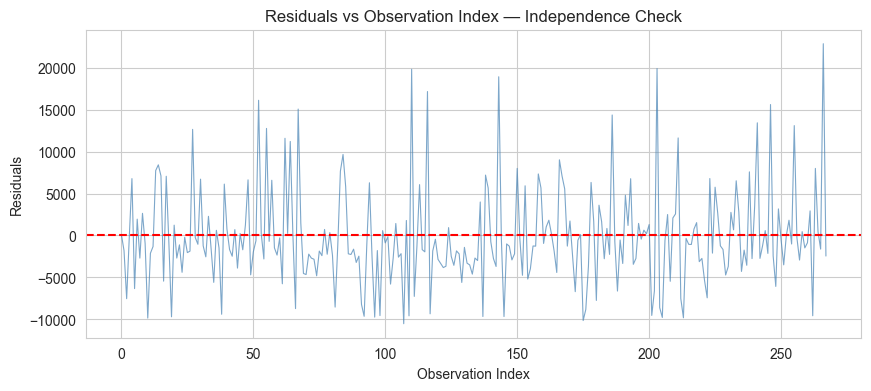

In [44]:
plt.figure(figsize=(10, 4))
plt.plot(residuals.values, color='steelblue', alpha=0.7, linewidth=0.8)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Observation Index — Independence Check')
plt.xlabel('Observation Index')
plt.ylabel('Residuals')
plt.show()

In [45]:
res_arr = residuals.values
dw = np.sum(np.diff(res_arr)**2) / np.sum(res_arr**2)
print(f'Durbin-Watson Statistic: {dw:.4f}')
print()
if 1.5 < dw < 2.5:
    print('→ DW ≈ 2 → No significant autocorrelation → Independence satisfied ')
elif dw < 1.5:
    print('→ DW < 1.5 → Positive autocorrelation detected ')
else:
    print('→ DW > 2.5 → Negative autocorrelation detected')

Durbin-Watson Statistic: 2.1905

→ DW ≈ 2 → No significant autocorrelation → Independence satisfied 


In [46]:
lag1_corr = np.corrcoef(res_arr[:-1], res_arr[1:])[0, 1]
print(f'Lag-1 Autocorrelation of Residuals: {lag1_corr:.4f}')
print('(Close to 0 → no autocorrelation)')

Lag-1 Autocorrelation of Residuals: -0.0971
(Close to 0 → no autocorrelation)


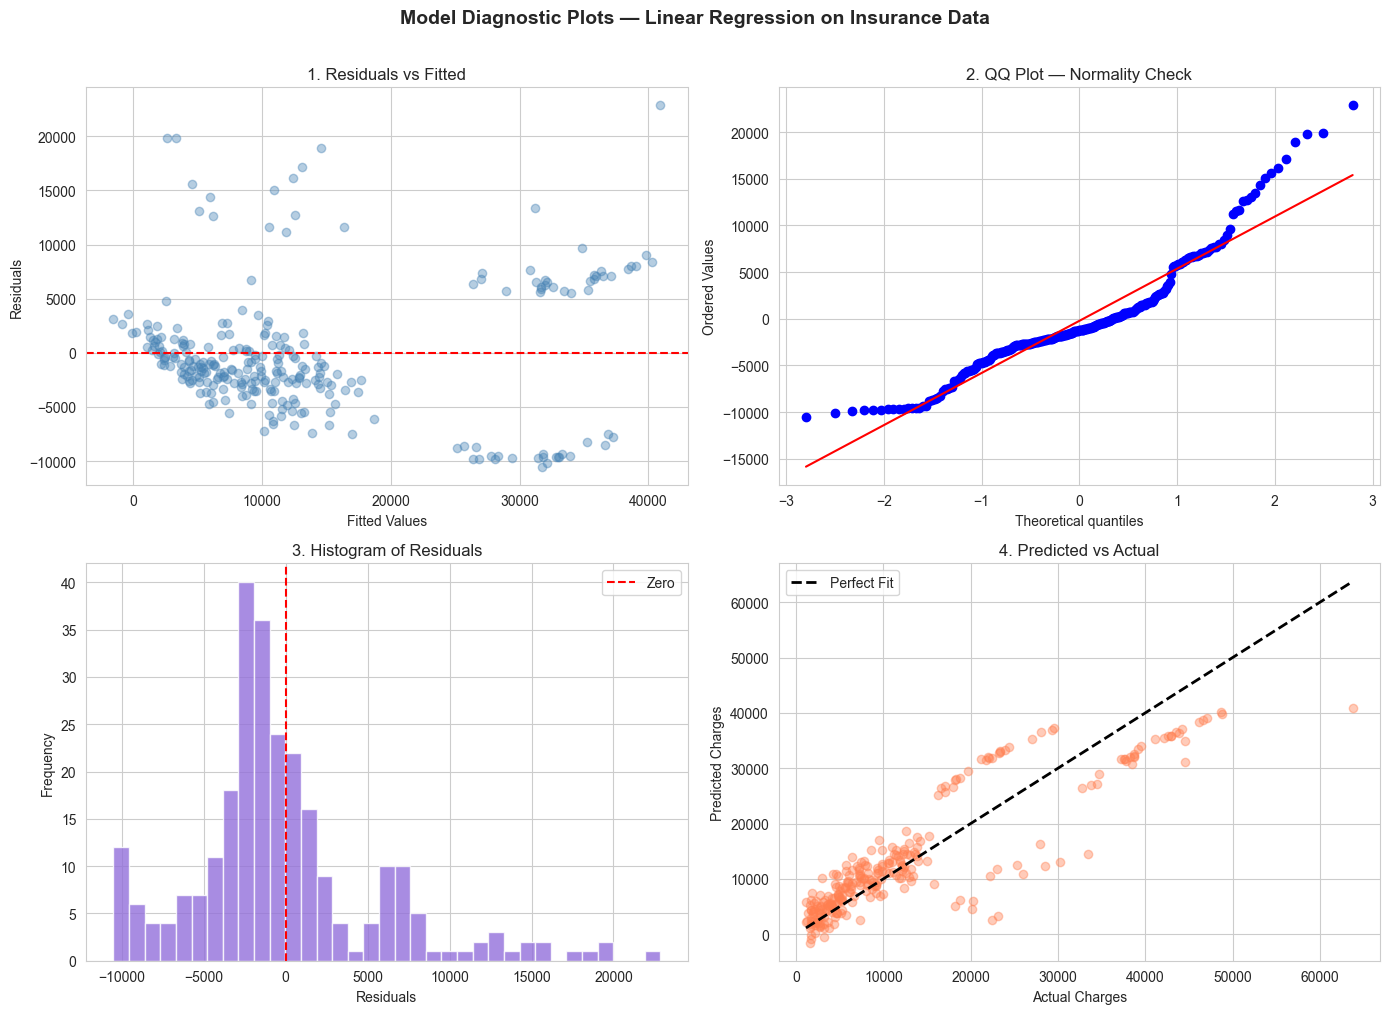

In [47]:
# 4-in-1 diagnostic plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.4, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('1. Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# 2. QQ Plot
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('2. QQ Plot — Normality Check')

# 3. Histogram of Residuals
axes[1, 0].hist(residuals, bins=35, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero')
axes[1, 0].set_title('3. Histogram of Residuals')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Predicted vs Actual
axes[1, 1].scatter(y_test, y_pred, alpha=0.4, color='coral')
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
axes[1, 1].set_title('4. Predicted vs Actual')
axes[1, 1].set_xlabel('Actual Charges')
axes[1, 1].set_ylabel('Predicted Charges')
axes[1, 1].legend()

plt.suptitle('Model Diagnostic Plots — Linear Regression on Insurance Data',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [48]:
y_log = np.log1p(df_encoded['charges'])
print(f'Original skewness : {df_encoded["charges"].skew():.4f}')
print(f'Log skewness      : {y_log.skew():.4f}')

Original skewness : 1.5159
Log skewness      : -0.0898


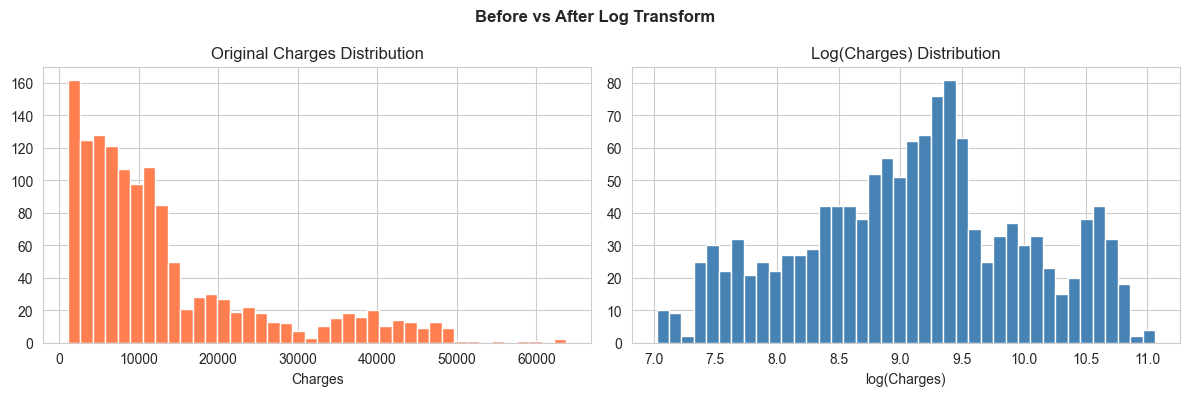

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_encoded['charges'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Original Charges Distribution')
axes[0].set_xlabel('Charges')

axes[1].hist(y_log, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Log(Charges) Distribution')
axes[1].set_xlabel('log(Charges)')

plt.suptitle('Before vs After Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

In [51]:
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

model_log = LinearRegression()
model_log.fit(X_train_l, y_train_l)
print('Log-transformed model trained!')

Log-transformed model trained!


In [52]:
# Predictions (back to original scale)
y_pred_log      = model_log.predict(X_test_l)        # log scale
y_pred_log_orig = np.expm1(y_pred_log)               # original scale
y_test_orig     = np.expm1(y_test_l)                 # original scale

# Residuals in log scale
residuals_log = y_test_l - y_pred_log
print('Log-scale residual stats:')
print(f'  Mean : {residuals_log.mean():.4f}')
print(f'  Std  : {residuals_log.std():.4f}')

Log-scale residual stats:
  Mean : -0.0411
  Std  : 0.4177


In [53]:
mae_log  = mean_absolute_error(y_test_orig, y_pred_log_orig)
rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred_log_orig))
r2_log   = r2_score(y_test_orig, y_pred_log_orig)

print('=== Log-Transformed Model ===')
print(f'  MAE  : {mae_log:,.2f}')
print(f'  RMSE : {rmse_log:,.2f}')
print(f'  R²   : {r2_log:.4f}')

=== Log-Transformed Model ===
  MAE  : 3,888.44
  RMSE : 7,814.06
  R²   : 0.6067


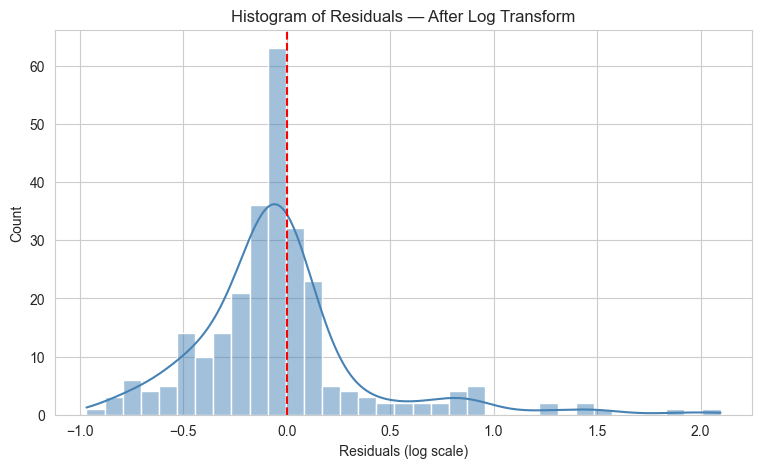

In [54]:
sns.histplot(residuals_log, kde=True, color='steelblue', bins=35)
plt.axvline(0, color='red', linestyle='--')
plt.title('Histogram of Residuals — After Log Transform')
plt.xlabel('Residuals (log scale)')
plt.show()

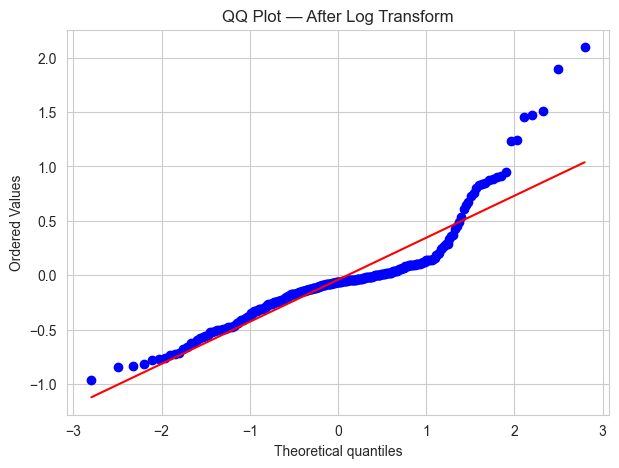

In [55]:
plt.figure(figsize=(7, 5))
stats.probplot(residuals_log, dist='norm', plot=plt)
plt.title('QQ Plot — After Log Transform')
plt.show()

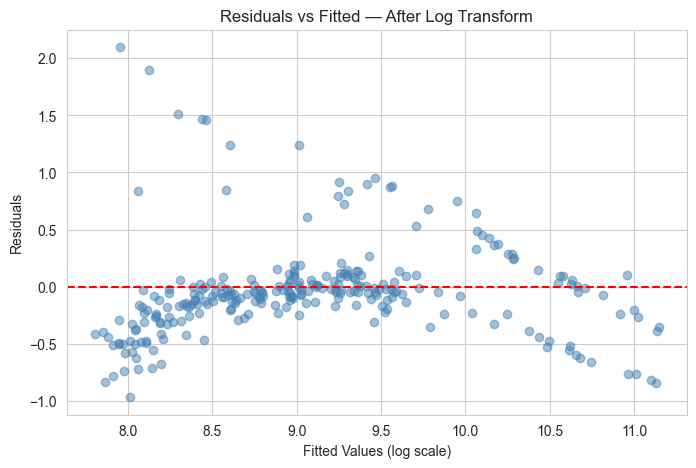

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_log, residuals_log, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted — After Log Transform')
plt.xlabel('Fitted Values (log scale)')
plt.ylabel('Residuals')
plt.show()

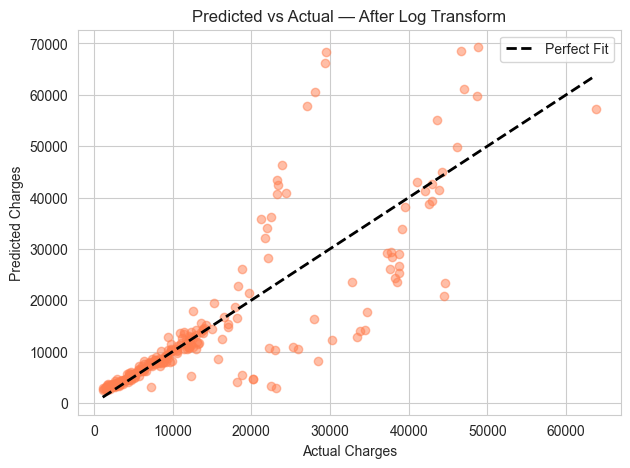

In [57]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_orig, y_pred_log_orig, alpha=0.5, color='coral')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Predicted vs Actual — After Log Transform')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.show()

In [58]:
sample_log = residuals_log[:500] if len(residuals_log) > 500 else residuals_log
stat_sw2, p_sw2 = shapiro(sample_log)
print(f'Shapiro-Wilk (after fix):')
print(f'  Statistic : {stat_sw2:.4f}')
print(f'  p-value   : {p_sw2:.6f}')
print()
if p_sw2 < 0.05:
    print('  → Still not perfectly normal, but significantly improved')
else:
    print('  → Residuals now normally distributed ')

Shapiro-Wilk (after fix):
  Statistic : 0.8471
  p-value   : 0.000000

  → Still not perfectly normal, but significantly improved


In [59]:
comparison = pd.DataFrame({
    'Model':  ['Baseline (original)', 'Fixed (log-transformed)'],
    'MAE':    [round(mae, 2),     round(mae_log, 2)],
    'RMSE':   [round(rmse, 2),    round(rmse_log, 2)],
    'R²':     [round(r2, 4),      round(r2_log, 4)]
})
comparison

,Model,MAE,RMSE,R²
0,Baseline (original),4181.19,5796.28,0.7836
1,Fixed (log-transformed),3888.44,7814.06,0.6067


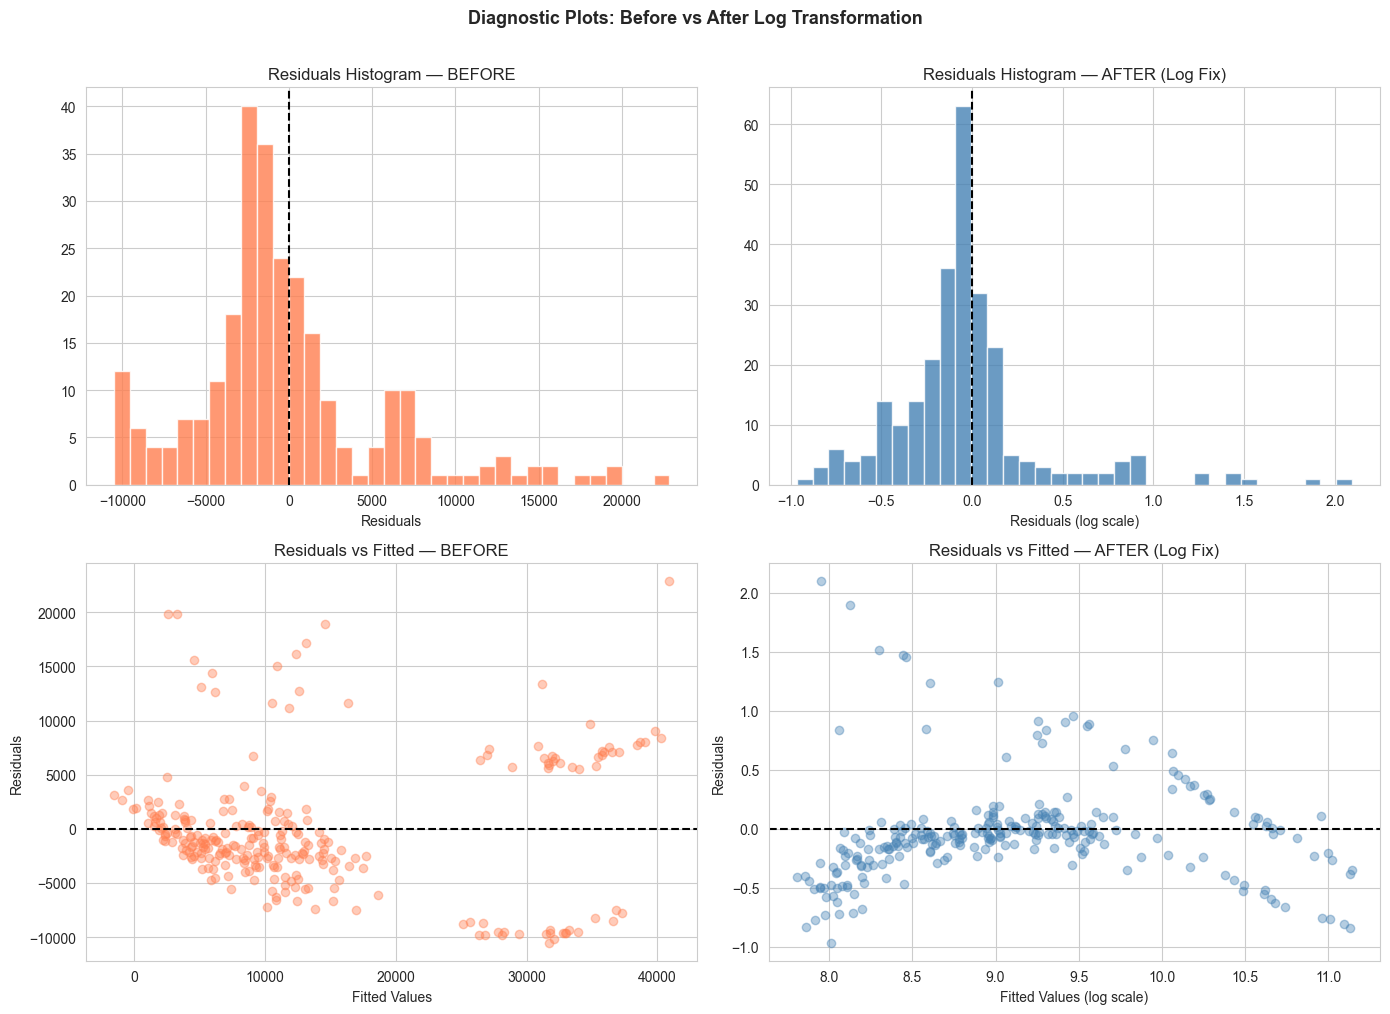

In [60]:
# Side-by-side 4-in-1 diagnostic: Before vs After
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual histogram: Before
axes[0, 0].hist(residuals, bins=35, color='coral', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(0, color='black', linestyle='--')
axes[0, 0].set_title('Residuals Histogram — BEFORE')
axes[0, 0].set_xlabel('Residuals')

# Residual histogram: After
axes[0, 1].hist(residuals_log, bins=35, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='black', linestyle='--')
axes[0, 1].set_title('Residuals Histogram — AFTER (Log Fix)')
axes[0, 1].set_xlabel('Residuals (log scale)')

# Residuals vs Fitted: Before
axes[1, 0].scatter(y_pred, residuals, alpha=0.4, color='coral')
axes[1, 0].axhline(0, color='black', linestyle='--')
axes[1, 0].set_title('Residuals vs Fitted — BEFORE')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('Residuals')

# Residuals vs Fitted: After
axes[1, 1].scatter(y_pred_log, residuals_log, alpha=0.4, color='steelblue')
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_title('Residuals vs Fitted — AFTER (Log Fix)')
axes[1, 1].set_xlabel('Fitted Values (log scale)')
axes[1, 1].set_ylabel('Residuals')

plt.suptitle('Diagnostic Plots: Before vs After Log Transformation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()